In [1]:
#%load_ext autoreload
#%autoreload 2

import os
from os.path import join
import random
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage import measure
from torch.utils.data import Dataset, DataLoader
import torchio as tio
from torchio.data import SubjectsLoader

from monai.networks.nets import UNet, AttentionUnet

os.environ["CUDA_VISIBLE_DEVICES"] = "0" # multiple ?
import torch
import torch.nn as nn
from pathlib import Path
from datetime import datetime

seed = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(seed)

In [2]:
import sys
print('__Python VERSION:', sys.version)
print('__pyTorch VERSION:', torch.__version__)
print('__CUDA VERSION')
from subprocess import call
! nvcc --version
print('__CUDNN VERSION:', torch.backends.cudnn.version())
print('__Number CUDA Devices:', torch.cuda.device_count())
print('__Devices')
call(["nvidia-smi", "--format=csv", "--query-gpu=index,name,driver_version,memory.total,memory.used,memory.free"])
print('Active CUDA Device: GPU', torch.cuda.current_device())
print ('Available devices ', torch.cuda.device_count())
print ('Current cuda device ', torch.cuda.current_device())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

__Python VERSION: 3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
__pyTorch VERSION: 2.8.0.dev20250416+cu128
__CUDA VERSION
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:42:46_Pacific_Standard_Time_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
__CUDNN VERSION: 90701
__Number CUDA Devices: 1
__Devices
Active CUDA Device: GPU 0
Available devices  1
Current cuda device  0


In [3]:
from utils.loading_utils import *
from utils.logging import *
from visualization.visualization import *
#from ml.dataset_ import BrainMetDatasetPreloaded, GridSamplerWrapper
from ml.dataset_ import BrainMetPytorchDataset, BrainMetFullVolumeDataset
from ml.trainer import Trainer, Att3DUNET_Trainer, load_trained_model

In [4]:
%load_ext tensorboard
%reload_ext tensorboard

%tensorboard --logdir runs

Launching TensorBoard...

In [5]:
#from tensorboard import notebook
#notebook.list()
#notebook.display(port=6006, height=1000)

#http://127.0.0.1:6006/?darkMode=true

In [6]:
TRAIN_ROOT_DIR  = './MICCAI-LH-BraTS2025-MET-Challenge-Training/'
HELPER_ROOT_DIR = './training_helper/'

# !--------------------------------------------------------------
dataset = BrainMetPytorchDataset(TRAIN_ROOT_DIR, patch_size=(128, 128, 96), do_raffine=True)
# !--------------------------------------------------------------

train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])

train_dataloader = DataLoader(train_dataset, batch_size=16, num_workers=0, shuffle=True)
validation_dataset = DataLoader(validation_dataset, batch_size=16, num_workers=0, shuffle=False)

Found UCSD-Training subfolder: ./training_helper/UCSD - Training
Total # samples: 6 in ./training_helper/



In [7]:
def dice_loss(probs, targets, epsilon=1e-5):
    # Assumes probs: [B, C, H, W, D], targets: [B, C, H, W, D]
    intersection = (probs * targets).sum(dim=(2, 3, 4))
    union = probs.sum(dim=(2, 3, 4)) + targets.sum(dim=(2, 3, 4))
    dice = 2. * intersection / (union + epsilon)
    return 1 - dice.mean()

def loss_fn(logits, target):
    target = target.to(torch.long)
    if target.ndim == 5 and target.shape[1] == 1:
        target = target[:, 0]              # [B, H, W, D]
    ce = torch.nn.functional.cross_entropy(logits, target)

    # --- Dice loss ---
    probs = torch.softmax(logits, dim=1)  # [B, C, H, W, D]
    one_hot_target = torch.nn.functional.one_hot(target, num_classes=logits.shape[1])  # [B, H, W, D, C]
    one_hot_target = one_hot_target.permute(0, 4, 1, 2, 3).float()    # [B, C, H, W, D]

    dice = dice_loss(probs, one_hot_target)

    return ce + dice

def dice_score(preds, targets, epsilon=1e-5):
    if targets.ndim == 5 and targets.shape[1] == 1:
        targets = targets[:, 0]  # Fix channel dim

    num_classes = int(torch.max(targets).item()) + 1
    dice_scores = []

    for c in range(num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()

        intersection = (pred_c * target_c).sum(dim=(1, 2, 3))
        union = pred_c.sum(dim=(1, 2, 3)) + target_c.sum(dim=(1, 2, 3))

        dice = (2 * intersection + epsilon) / (union + epsilon)
        dice_scores.append(dice)

    return torch.stack(dice_scores).mean()

# Run1

In [8]:
from ml.a3d_attention_unet import UNet3D

model_1 = UNet3D(
    in_channels=4,
    out_channels=5,
    final_sigmoid=False,
    f_maps = 32,
    layer_order='crg',
    num_groups=8
)
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=1.5e-4, weight_decay=5e-3)

Epoch: 1 [train-loss]:   0%|          | 0/1 [00:00<?, ?it/s]D:\Schule\JKU\MA_2_Semester\MedicalImaging\ml\trainer.py:444: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Scalar.cpp:23.)
  losses.append(loss_value.item())
Epoch: 1 [valid-loss]: 100%|██████████| 1/1 [00:47<00:00, 47.76s/it, valid-loss_loss=2.5076]



Epoch Summary:
  train-loss: 2.4361
  mean-dice-score: 0.1124
  WT-Dice: 0.0000
  TC-Dice: 1.0000
  ET-Dice: 0.0000
  WT-NSD: 0.0000
  WT-Sensitivity: 0.9660
  WT-Specificity: 0.2896
  WT-Precision: 0.0000
  TC-NSD: 0.0000
  TC-Sensitivity: 0.6364
  TC-Specificity: 0.3246
  TC-Precision: 0.0000
  ET-NSD: 0.0000
  ET-Sensitivity: 0.0909
  ET-Specificity: 0.8800
  ET-Precision: 0.0000
  valid-loss: 2.5076


Epoch: 2 [valid-loss]: 100%|██████████| 1/1 [00:09<00:00,  9.67s/it, valid-loss_loss=2.5090]



Epoch Summary:
  train-loss: 2.4147
  mean-dice-score: 0.1032
  WT-Dice: 0.0003
  TC-Dice: 1.0000
  ET-Dice: 0.0000
  WT-NSD: 0.0002
  WT-Sensitivity: 0.9949
  WT-Specificity: 0.2584
  WT-Precision: 0.0002
  TC-NSD: 0.0001
  TC-Sensitivity: 0.4000
  TC-Specificity: 0.3061
  TC-Precision: 0.0000
  ET-NSD: 0.0002
  ET-Sensitivity: 0.2000
  ET-Specificity: 0.8677
  ET-Precision: 0.0000
  valid-loss: 2.5090


Epoch: 3 [valid-loss]: 100%|██████████| 1/1 [00:07<00:00,  7.77s/it, valid-loss_loss=2.5061]



Epoch Summary:
  train-loss: 2.4016
  mean-dice-score: 0.1446
  WT-Dice: 0.0001
  TC-Dice: 1.0000
  ET-Dice: 0.0000
  WT-NSD: 0.0001
  WT-Sensitivity: 0.9403
  WT-Specificity: 0.2769
  WT-Precision: 0.0001
  TC-NSD: 0.0000
  TC-Sensitivity: 0.0000
  TC-Specificity: 0.3082
  TC-Precision: 0.0000
  ET-NSD: 0.0000
  ET-Sensitivity: 0.0000
  ET-Specificity: 0.8755
  ET-Precision: 0.0000
  valid-loss: 2.5061


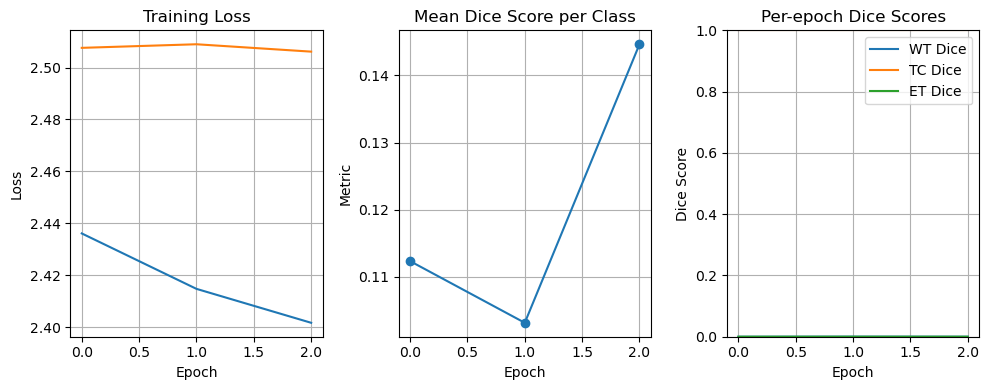

In [9]:
num_epochs = 10 # change to 50
dir = f'./runs/run_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
progress = ProgressBar()
tb = TensorBoard(path=dir)
checkpoints = Backup(path=dir, every=5)

trainer_1 = Att3DUNET_Trainer(model_1, optimizer_1, loss_fn, dice_score, device=device, use_torchio=False)
checkpoints.attach_trainer(trainer_1)
trainer_1.tracker.loggers = [progress, tb, checkpoints]

trainer_1.train(train_loader=train_dataloader, val_loader=validation_dataset, epochs=num_epochs)

In [11]:
VALIDATION_ROOT_DIR  = './MICCAI-LH-BraTS2025-MET-Challenge-Validation/'

fullval_dataset = BrainMetFullVolumeDataset(root_dir=VALIDATION_ROOT_DIR)
full_validation_dataset = DataLoader(fullval_dataset, batch_size=1, num_workers=0, shuffle=False)

In [12]:
import os
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm

# === Setup ===
model_1.eval()
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
save_dir = f"./results/res_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

# === Inference Loop ===
for i, (inputs, datapoint_name) in enumerate(tqdm(full_validation_dataset, desc="Predicting")):
    inputs = inputs.to("cuda")

    with torch.no_grad():
        logits, _ = model_1(inputs)
        preds = torch.argmax(logits, dim=1)

    pred_np = preds.squeeze(0).cpu().numpy().astype(np.uint8)
    affine = np.eye(4)  # You could optionally load one of the input affines here

    pred_nii = nib.Nifti1Image(pred_np, affine)
    save_path = os.path.join(save_dir, datapoint_name[0] + "-seg.nii.gz")
    nib.save(pred_nii, save_path)


Predicting: 100%|██████████| 5/5 [00:15<00:00,  3.02s/it]


# Run2